In [172]:
import pandas as pd

In [173]:
data = pd.read_csv("housing.csv")

In [174]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [175]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [176]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [177]:
data.duplicated().sum()

np.int64(0)

In [178]:
data.shape

(20640, 10)

In [179]:
data["longitude"].nunique()

844

In [180]:
data.select_dtypes(float)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [181]:
data.select_dtypes(object)

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


<Axes: ylabel='total_bedrooms'>

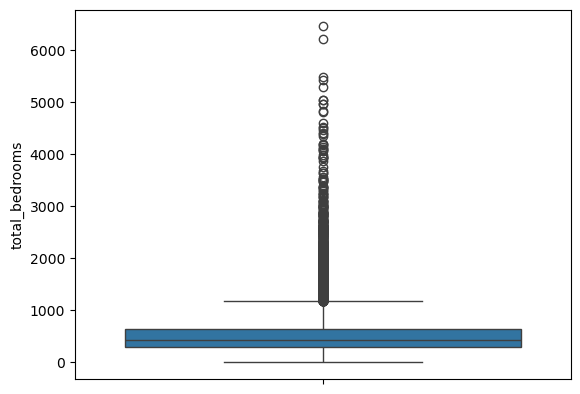

In [182]:
import seaborn as sns
sns.boxplot(data.total_bedrooms)

In [183]:
outlier is far then filling data median
outluer is near then fillinf data mean

SyntaxError: invalid syntax (914514385.py, line 1)

In [203]:
data.total_bedrooms.fillna(data.total_bedrooms.mean(), inplace=True)

In [204]:
data.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

<Axes: xlabel='longitude', ylabel='median_house_value'>

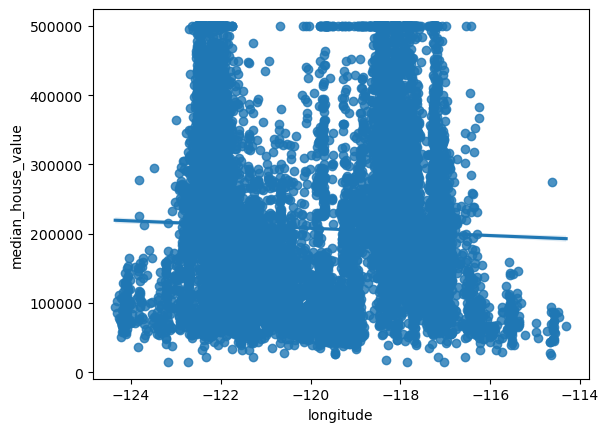

In [205]:
sns.regplot(data, x= data.longitude, y = data.median_house_value)

<Axes: xlabel='latitude', ylabel='median_house_value'>

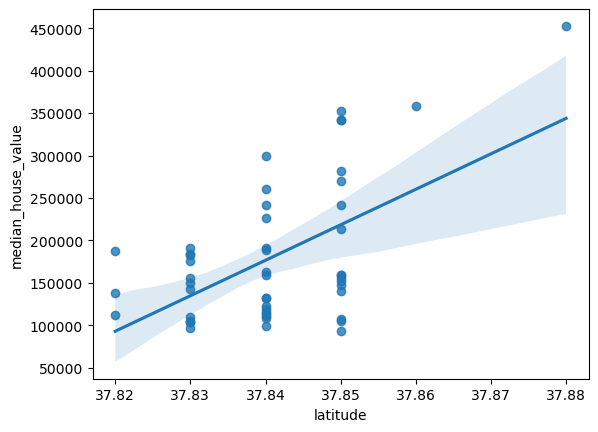

In [206]:
sns.regplot(data, x= data.latitude.head(50)             , y = data.median_house_value.head(50))

<Axes: xlabel='total_bedrooms', ylabel='median_house_value'>

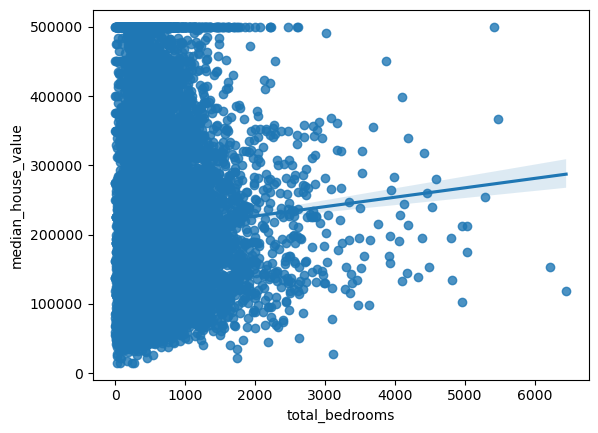

In [207]:
 sns.regplot(data, x= data.total_bedrooms, y = data.median_house_value)

<Axes: xlabel='population', ylabel='median_house_value'>

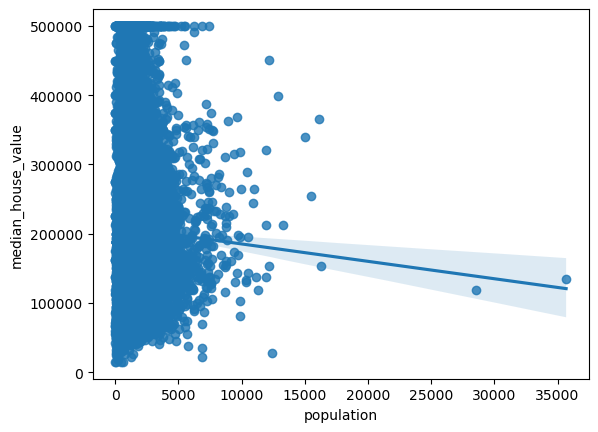

In [208]:
sns.regplot(data , x= data.population            , y= data.median_house_value)

In [209]:
data.ocean_proximity.value_counts()

AttributeError: 'DataFrame' object has no attribute 'ocean_proximity'

In [ ]:
data.drop(["ocean_proximity"], axis = 1, inplace =True)

In [ ]:
data.corr()

In [ ]:
X = data.drop("median_house_value",axis = 1)
y = data.median_house_value

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=42)

In [210]:
X_train.shape

(14448, 8)

In [211]:
y_train.shape

(14448,)

In [212]:
X_test.shape

(6192, 8)

In [213]:
y_test.shape

(6192,)

# Linear regression

In [214]:
from sklearn.linear_model import LinearRegression

In [215]:
lr = LinearRegression()

In [216]:
lr.fit(X_train,y_train)

LinearRegression()

### Using Score method

In [217]:
lr.score(X_train,y_train)

0.6368463107869556

### Seperate 


In [218]:
y_train_pred = lr.predict(X_train)

### Training Data 

In [219]:
from sklearn.metrics import r2_score, mean_absolute_error

In [220]:
r2_score(y_train,y_train_pred)  # accuracy

0.6368463107869556

In [221]:
mean_absolute_error(y_train,y_train_pred)  # lose

50822.0630783091

### Testing Data

In [222]:
y_pred_test= lr.predict(X_test) 

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [223]:
r2_score(y_test,y_pred_test)  # accuracy

0.6303305386065021

In [224]:
mean_absolute_error(y_test, y_pred_test)  # lose

51066.10133009406

In [225]:
lr.coef_

array([-4.26430157e+04, -4.23108503e+04,  1.18516310e+03, -8.05495391e+00,
        1.19513915e+02, -3.75647763e+01,  3.97022468e+01,  4.03610310e+04])

In [226]:
lr.intercept_

np.float64(-3583900.464809611)

In [227]:
l1 = Lasso Regularization
            ---

SyntaxError: invalid syntax (2881763602.py, line 1)

# Lasso

In [228]:
from sklearn.linear_model import LassoCV, Lasso

In [229]:
lasso=LassoCV(alphas=[1.0,0.01,0.1,0.12,0.90])

In [230]:
lasso.fit(X_train,y_train)

LassoCV(alphas=[1.0, 0.01, 0.1, 0.12, 0.9])

In [231]:
lasso.alpha_

np.float64(1.0)

In [232]:
lasoo_y_train_pred=lasso.predict(X_train)

In [233]:
r2_score(y_train,lasoo_y_train_pred)

0.6368463102739259

# Ridge

In [234]:
from sklearn.linear_model import RidgeCV

In [235]:
ridgelasso=RidgeCV()

In [236]:
ridgelasso.fit(X_train,y_train)

RidgeCV()

In [237]:
ridgelasso.alpha_

np.float64(10.0)

In [238]:
ridge_y_train_pred=ridgelasso.predict(X_train)

In [239]:
r2_score(y_train,ridge_y_train_pred)

0.6368458608808255

### overfitting = Trainning mai performance high hon aur testing mai low hon
### underfitting= Trainning mai perfromance low hon aur testiung mai low hon
### bestfit = Training mai perfromaance high hon aur testing mai high hon

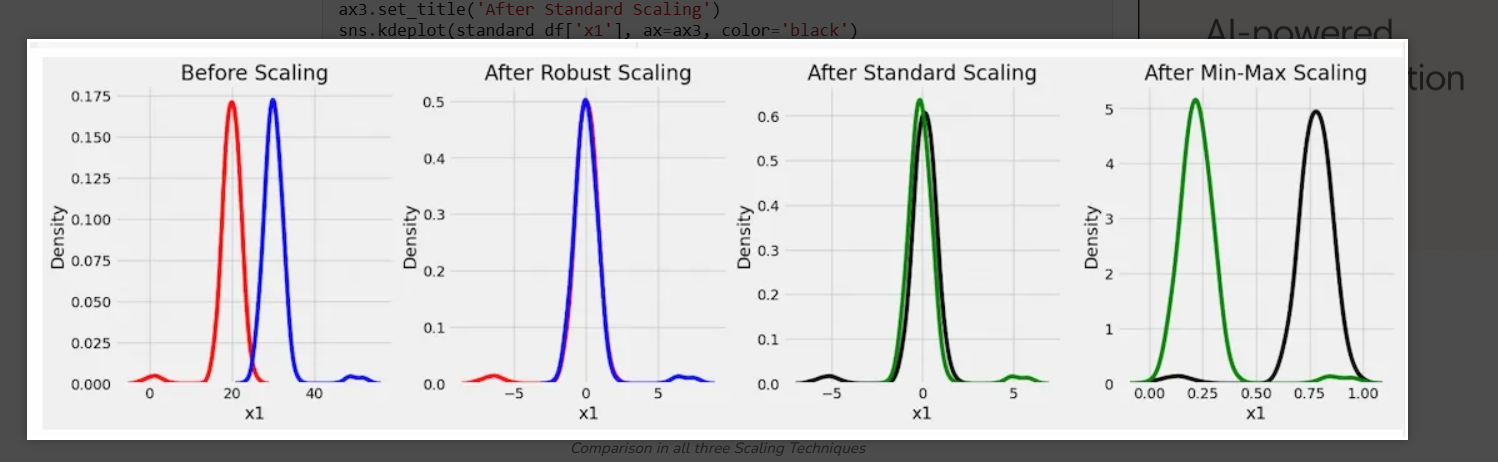